# Algorithmic Credit Risk Decision Support

This empirical Information Systems notebook predicts whether a loan will end as **Fully Paid** or **Charged Off / Default** using historical LendingClub borrower and loan features. It studies how predictive-model choices shape decision support in a high-stakes, class-imbalanced setting.

Because this is a credit-risk problem with class imbalance, the analysis does **not** rely on accuracy alone. It evaluates **recall, F1-score, ROC-AUC, and confusion matrices** to make visible how class weighting and threshold selection redistribute missed defaults and additional review cases.

The **Class-Weighted ANN** is retained as the focal ANN specification because it gives the strongest balance for the stated objective, but the simpler benchmarks remain competitive. The resulting risk bands are illustrative aids for human review—not an official credit score, an automated underwriting rule, or evidence of causal effects.


## 1. Data Cleaning and Preprocessing


In [ ]:
from pathlib import Path
import os
import pandas as pd

# Set LENDINGCLUB_DATA to the cleaned Feather file, or place it under data/.
DATA_PATH = Path(os.getenv('LENDINGCLUB_DATA', '../data/lending_club_clean.feather'))
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. See data/README.md for setup instructions.'
    )
df = pd.read_feather(DATA_PATH)
print(f'Loaded {len(df):,} rows from {DATA_PATH}')


In [3]:
summary = pd.DataFrame({
    'Total': df.shape[0],
    'Non-Null': df.count(),
    'Null': df.isnull().sum(),
    'Null %': round(df.isnull().sum() / df.shape[0] * 100, 2),
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes
})
print(summary)

                                              Total  Non-Null     Null  \
id                                          2925492   2925492        0   
loan_amnt                                   2925492   2925492        0   
funded_amnt                                 2925492   2925492        0   
funded_amnt_inv                             2925492   2925492        0   
term                                        2925492   2925492        0   
...                                             ...       ...      ...   
hardship_loan_status                        2925492    143411  2782081   
orig_projected_additional_accrued_interest  2925492   2925492        0   
hardship_payoff_balance_amount              2925492   2925492        0   
hardship_last_payment_amount                2925492   2925492        0   
debt_settlement_flag                        2925492   2925492        0   

                                            Null %  Unique Values Data Type  
id                               

In [4]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64


In [5]:
#Keep only Fully Paid, Charged Off, and Default
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]

# 1 = default/charged off, 0 = fully paid
df['target'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

print(df['target'].value_counts())
print()
print('0 = Fully Paid')
print('1 = Default / Charged Off')
print('Total:', df.shape[0])

target
0    1497783
1     362981
Name: count, dtype: int64

0 = Fully Paid
1 = Default / Charged Off
Total: 1860764


In [6]:
#Columns to keep
keep_columns = [
    'loan_amnt',          # how much borrower wants
    'term',               # 36 or 60 months
    'int_rate',           # interest rate assigned by LC
    'installment',        # monthly payment amount
    'grade',              # LC assigned loan grade (A-G)
    'sub_grade',          # LC assigned sub grade (A1-G5)
    'emp_length',         # years employed
    'home_ownership',     # rent, own, mortgage
    'annual_inc',         # borrower income
    'verification_status',# income verified or not
    'purpose',            # why they want the loan
    'dti',                # debt-to-income ratio
    'addr_state',         # state
    'fico_range_low',     # FICO score low
    'fico_range_high',    # FICO score high
    'earliest_cr_line',   # when first credit line opened
    'open_acc',           # number of open credit lines
    'total_acc',          # total credit lines
    'revol_bal',          # revolving balance
    'revol_util',         # revolving utilization rate
    'pub_rec',            # public records (negative marks)
    'pub_rec_bankruptcies',# bankruptcies
    'delinq_2yrs',        # delinquencies in past 2 years
    'inq_last_6mths',     # credit inquiries in past 6 months
    'mort_acc',           # number of mortgage accounts
    'target'              # 0 = fully paid, 1 = default
]

#Keep only these columns
df = df[keep_columns]
print(df.shape)
print(df.columns.tolist())

(1860764, 26)
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'addr_state', 'fico_range_low', 'fico_range_high', 'earliest_cr_line', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'pub_rec', 'pub_rec_bankruptcies', 'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'target']


In [7]:
#Check missing values
print(df.isnull().sum())

loan_amnt                    0
term                         0
int_rate                     0
installment                  0
grade                        0
sub_grade                    0
emp_length              117260
home_ownership               0
annual_inc                   0
verification_status          0
purpose                      0
dti                          0
addr_state                   0
fico_range_low               0
fico_range_high              0
earliest_cr_line             0
open_acc                     0
total_acc                    0
revol_bal                    0
revol_util                1398
pub_rec                      0
pub_rec_bankruptcies         0
delinq_2yrs                  0
inq_last_6mths               0
mort_acc                     0
target                       0
dtype: int64


In [8]:
#Drop rows with missing values
df = df.dropna()
print('Rows remaining:', df.shape[0])

Rows remaining: 1742209


In [9]:
#Random sample 200,000 rows
from sklearn.model_selection import train_test_split

df_sample = df.sample(n=200000, random_state=42)
print('Sample size:', df_sample.shape[0])
print(df_sample['target'].value_counts())

Sample size: 200000
target
0    161838
1     38162
Name: count, dtype: int64


In [10]:
#Split into train (160000), validation (20000), test (20000)
from sklearn.model_selection import train_test_split
# First split: 80% train, 20% leftover
train, leftover = train_test_split(df_sample, train_size=0.8, random_state=42, stratify=df_sample['target'])

# Second split: split the 20% leftover in half
val, test = train_test_split(leftover, test_size=0.5, random_state=42, stratify=leftover['target'])

print('Train:', train.shape[0])
print('Validation:', val.shape[0])
print('Test:', test.shape[0])
print()
print('Train default ratio:', round(train['target'].mean(), 4))
print('Val default ratio:', round(val['target'].mean(), 4))
print('Test default ratio:', round(test['target'].mean(), 4))

Train: 160000
Validation: 20000
Test: 20000

Train default ratio: 0.1908
Val default ratio: 0.1908
Test default ratio: 0.1908


The project keeps an **80 / 10 / 10** split:
- **80% training**
- **10% validation**
- **10% test**

This final notebook does **not** change that split. The validation set is used for ANN monitoring and tuning, and the test set is reserved for final comparison.


In [11]:
#Check data types
print(train.dtypes)

loan_amnt                        Int32
term                             Int16
int_rate                       float32
installment                    float32
grade                         category
sub_grade                     category
emp_length                    category
home_ownership                category
annual_inc                     float32
verification_status           category
purpose                       category
dti                            float32
addr_state                    category
fico_range_low                   Int32
fico_range_high                  Int32
earliest_cr_line        datetime64[ns]
open_acc                         Int16
total_acc                        Int16
revol_bal                        Int64
revol_util                     float32
pub_rec                          Int16
pub_rec_bankruptcies             Int16
delinq_2yrs                      Int16
inq_last_6mths                   Int16
mort_acc                         Int16
target                   

In [12]:
#Look at earliest_cr_line values
print(train['earliest_cr_line'].head(10))

2164021   2001-11-01
375285    2010-05-01
461318    2004-10-01
61238     1989-05-01
1018114   2001-08-01
1591795   2002-08-01
397822    2003-05-01
2443569   1992-02-01
117020    2000-06-01
2531150   1996-07-01
Name: earliest_cr_line, dtype: datetime64[ns]


In [13]:
#Look at sample values of category columns
print('Grade:', train['grade'].unique())
print('Home:', train['home_ownership'].unique())
print('Verification:', train['verification_status'].unique())
print('Purpose:', train['purpose'].unique())
print('Emp Length:', train['emp_length'].unique())
print('Term:', train['term'].unique())

Grade: ['A', 'B', 'C', 'D', 'F', 'G', 'E']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Home: ['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'ANY', 'NONE']
Categories (6, object): ['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']
Verification: ['Not Verified', 'Verified', 'Source Verified']
Categories (3, object): ['Not Verified', 'Source Verified', 'Verified']
Purpose: ['credit_card', 'other', 'debt_consolidation', 'car', 'home_improvement', ..., 'vacation', 'moving', 'wedding', 'renewable_energy', 'educational']
Length: 14
Categories (14, object): ['car', 'credit_card', 'debt_consolidation', 'educational', ...,
                          'renewable_energy', 'small_business', 'vacation', 'wedding']
Emp Length: ['7 years', '4 years', '10+ years', '9 years', '1 year', ..., '< 1 year', '2 years', '6 years', '8 years', '5 years']
Length: 11
Categories (11, object): ['1 year', '10+ years', '2 years', '3 years', ..., '7 years', '8 years',
                          '9 years', '< 1 year

In [14]:
#Convert earliest_cr_line to years of credit history
import pandas as pd

train['credit_history_years'] = (pd.Timestamp.today() - train['earliest_cr_line']).dt.days / 365
val['credit_history_years'] = (pd.Timestamp.today() - val['earliest_cr_line']).dt.days / 365
test['credit_history_years'] = (pd.Timestamp.today() - test['earliest_cr_line']).dt.days / 365

# Drop the original date column
train = train.drop('earliest_cr_line', axis=1)
val = val.drop('earliest_cr_line', axis=1)
test = test.drop('earliest_cr_line', axis=1)

print(train['credit_history_years'].head())

2164021    24.471233
375285     15.969863
461318     21.553425
61238      36.983562
1018114    24.723288
Name: credit_history_years, dtype: float64


In [15]:
#Convert emp_length to numbers
emp_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

train['emp_length'] = train['emp_length'].map(emp_map)
val['emp_length'] = val['emp_length'].map(emp_map)
test['emp_length'] = test['emp_length'].map(emp_map)

print(train['emp_length'].head())

2164021     7
375285      4
461318     10
61238      10
1018114     7
Name: emp_length, dtype: category
Categories (11, int64): [1, 10, 2, 3, ..., 7, 8, 9, 0]


In [16]:
#Drop sub_grade (grade already captures this) and addr_state (51 states = too many columns)
train = train.drop(['sub_grade', 'addr_state'], axis=1)
val = val.drop(['sub_grade', 'addr_state'], axis=1)
test = test.drop(['sub_grade', 'addr_state'], axis=1)

print('Columns remaining:', train.shape[1])

Columns remaining: 24


In [17]:
# Save a business-readable copy of the test set before one-hot encoding
# This will be used later for model-based scoring and loan-readiness output
test_scoring_base = test.copy().reset_index(drop=True)
print('Saved business-readable test set for scoring:', test_scoring_base.shape)


Saved business-readable test set for scoring: (20000, 24)


In [18]:
#One-hot encode category columns
cat_columns = ['grade', 'home_ownership', 'verification_status', 'purpose']

train = pd.get_dummies(train, columns=cat_columns)
val = pd.get_dummies(val, columns=cat_columns)
test = pd.get_dummies(test, columns=cat_columns)

# Make sure all three sets have the same columns
# (in case a category only appears in one set)
train, val = train.align(val, join='left', axis=1, fill_value=0)
train, test = train.align(test, join='left', axis=1, fill_value=0)

print('Total columns after one-hot encoding:', train.shape[1])
print(train.columns.tolist())

Total columns after one-hot encoding: 50
['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'pub_rec', 'pub_rec_bankruptcies', 'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'target', 'credit_history_years', 'grade_A', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


In [19]:
#Separate feature(X) and target(y)
X_train = train.drop('target', axis=1).astype('float32')
y_train = train['target'].values.astype('float32')

X_val = val.drop('target', axis=1).astype('float32')
y_val = val['target'].values.astype('float32')

X_test = test.drop('target', axis=1).astype('float32')
y_test = test['target'].values.astype('float32')

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (160000, 49)
y_train shape: (160000,)


In [20]:
#Normalize - subtract mean and divide by standard deviation
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print('X_train shape:', X_train.shape)
print('Sample values:')
print(X_train.iloc[0])

X_train shape: (160000, 49)
Sample values:
loan_amnt                              0.246575
term                                  -0.590380
int_rate                              -1.345562
installment                            0.289276
emp_length                             0.286238
annual_inc                             0.904182
dti                                   -0.552182
fico_range_low                         0.069467
fico_range_high                        0.069466
open_acc                              -0.485094
total_acc                             -0.805205
revol_bal                             -0.353520
revol_util                            -0.624369
pub_rec                               -0.344935
pub_rec_bankruptcies                  -0.345020
delinq_2yrs                           -0.365723
inq_last_6mths                        -0.681927
mort_acc                               0.239252
credit_history_years                  -0.238720
grade_A                                2.0928

In [21]:
#Fix NaN from normalization
#Drop columns that were all zeros (std = 0)
zero_cols = std[std == 0].index.tolist()
print('Dropping all-zero columns:', zero_cols)

X_train = X_train.drop(zero_cols, axis=1)
X_val = X_val.drop(zero_cols, axis=1)
X_test = X_test.drop(zero_cols, axis=1)

#Fill any remaining NaN just in case
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

print('Final X_train shape:', X_train.shape)
print('Any NaN left:', X_train.isnull().sum().sum())

Dropping all-zero columns: []
Final X_train shape: (160000, 49)
Any NaN left: 0


In [22]:
#train_save = X_train.copy()
#train_save['target'] = y_train

#val_save = X_val.copy()
#val_save['target'] = y_val

#test_save = X_test.copy()
#test_save['target'] = y_test



The dataset was cleaned and filtered to keep only the final loan outcomes relevant to this project.  
Categorical variables were converted into numeric form through one-hot encoding, and the features were standardized using the training-set mean and standard deviation.  
This preprocessing creates a consistent feature space for ANN modeling while preserving the original **80 / 10 / 10** train-validation-test split used in the final implementation.


## 2. ANN Model Development

The first ANN in this notebook is a **regularized neural network with Dropout**, rather than a separate baseline-only model.
This keeps the project closer to the course emphasis on **ANN design, regularization, and tuning**.

The model uses:
- fully connected hidden layers with **ReLU**
- **Dropout** to reduce overfitting
- a **sigmoid** output layer for binary classification
- callback-based training with **EarlyStopping** and **ReduceLROnPlateau**


### Training Strategy

All ANN models below use a shared callback-based training strategy.
Instead of fixing an arbitrary epoch count, the notebook sets a high maximum epoch limit and lets validation performance decide when to stop.

For a more stable training process, the ANN models use:
- **Adam learning rate = 0.0005**
- **EarlyStopping patience = 8**
- **ReduceLROnPlateau patience = 3**

This slows training slightly and gives the model more time to improve before stopping.


In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import models, layers
from keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

MAX_EPOCHS = 100
BATCH_SIZE = 512
INITIAL_LR = 5e-4

def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
    return [early_stop, reduce_lr]

def evaluate_prob_model(model_name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return results, y_pred

def print_results_table(results_dict):
    df_results = __import__('pandas').DataFrame([results_dict])
    display(df_results.round(4))


> Because this notebook was rebuilt around a Dropout-based first ANN model, rerun **Sections 2–6** to generate a fully consistent set of outputs.


In [24]:
# Build the core ANN model with Dropout

core_ann_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

core_ann_model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

core_ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the core ANN model

history_core_ann = core_ann_model.fit(
    X_train,
    y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks()
)

best_epoch_core_ann = int(np.argmin(history_core_ann.history['val_loss'])) + 1
trained_epochs_core_ann = len(history_core_ann.history['loss'])

print('Training stopped after', trained_epochs_core_ann, 'epochs')
print('Best validation-loss epoch:', best_epoch_core_ann)


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7903 - loss: 0.4990 - val_accuracy: 0.8094 - val_loss: 0.4529 - learning_rate: 5.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8084 - loss: 0.4661 - val_accuracy: 0.8094 - val_loss: 0.4492 - learning_rate: 5.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8087 - loss: 0.4598 - val_accuracy: 0.8096 - val_loss: 0.4478 - learning_rate: 5.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8092 - loss: 0.4557 - val_accuracy: 0.8095 - val_loss: 0.4466 - learning_rate: 5.0000e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8093 - loss: 0.4536 - val_accuracy: 0.8094 - val_loss: 0.4457 - learning_rate: 5.0000e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8093 - loss: 0.4519 - val_accuracy: 0.8092 - val_loss: 0.4452 - learning_rate: 5.0000e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc

In [26]:

def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

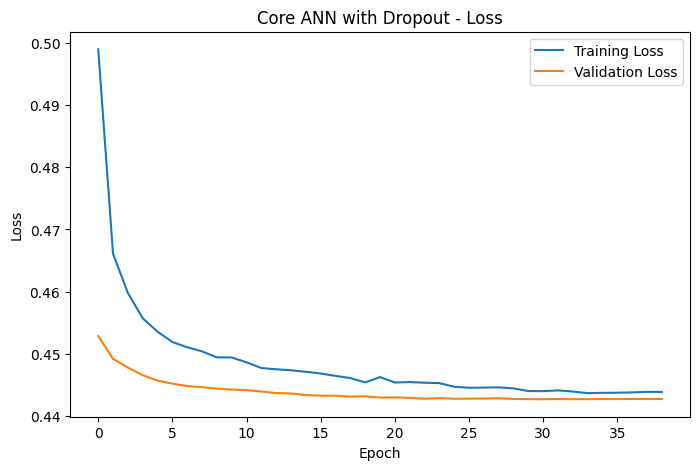

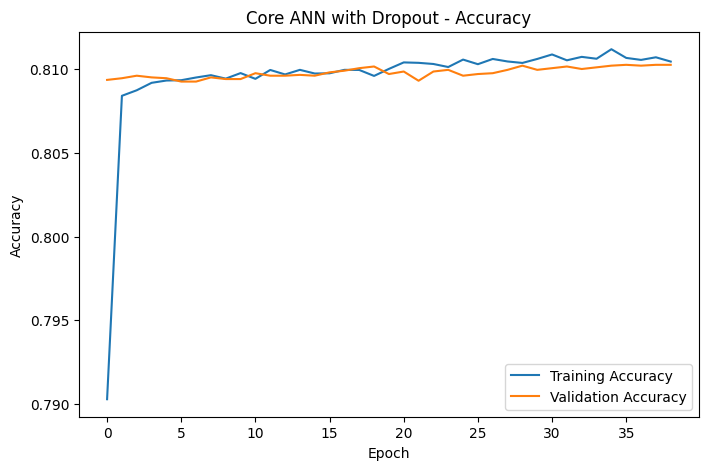

In [27]:
# Plot training history for the core ANN model

plot_training_history(history_core_ann, 'Core ANN with Dropout')


In [28]:
# Evaluate the core ANN model on the test set

test_loss_core_ann, test_accuracy_core_ann = core_ann_model.evaluate(X_test, y_test)

print("Core ANN test loss:", test_loss_core_ann)
print("Core ANN test accuracy:", test_accuracy_core_ann)

y_prob_core_ann = core_ann_model.predict(X_test).ravel()
core_ann_results, y_pred_core_ann = evaluate_prob_model(
    'Regularized ANN (Dropout)',
    y_test,
    y_prob_core_ann
)

print_results_table(core_ann_results)


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8103 - loss: 0.4434
Core ANN test loss: 0.44344502687454224
Core ANN test accuracy: 0.8102999925613403
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regularized ANN (Dropout),0.8103,0.5688,0.0238,0.0458,0.7102


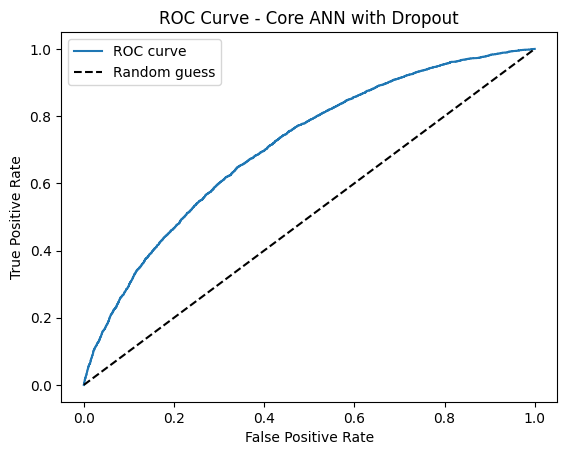

In [29]:
# ROC curve for the core ANN model

fpr_core_ann, tpr_core_ann, thresholds_core_ann = roc_curve(y_test, y_prob_core_ann)

plt.figure()
plt.plot(fpr_core_ann, tpr_core_ann, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title('ROC Curve - Core ANN with Dropout')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


The first ANN model already uses **dropout regularization** and callback-based training, so it is a stronger starting point than a plain baseline network.

After rerunning the notebook, this Regularized ANN reached **0.8103 accuracy** and **0.7102 ROC-AUC**, but its **recall was only 0.0238** and its **F1-score was 0.0458**.  
This means the default 0.5 cutoff made the model too conservative: it classified many loans correctly overall, but it missed most of the actual default cases. For this credit-risk task, that is not a strong final business result.


## 3. Business-Oriented Rebalancing

Because loan default data is imbalanced, the next step is to test business-oriented rebalancing strategies.
The two main adjustments in this section are:
- **threshold tuning**
- **class-weighted training**


### 3.1 Threshold Tuning


In [30]:
# Evaluate the same ANN probabilities with a lower threshold

threshold_03 = 0.3
threshold_ann_results, y_pred_threshold_03 = evaluate_prob_model(
    'Threshold-Tuned ANN (0.3)',
    y_test,
    y_prob_core_ann,
    threshold=threshold_03
)

print_results_table(threshold_ann_results)

print("Predicted class counts at 0.3 threshold:", np.bincount(y_pred_threshold_03))


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Threshold-Tuned ANN (0.3),0.7738,0.3964,0.3548,0.3744,0.7102


Predicted class counts at 0.3 threshold: [16584  3416]


In [31]:
# Compare the default 0.5 threshold with the lower 0.3 threshold

threshold_comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Regularized ANN (0.5)': [
        core_ann_results['Accuracy'],
        core_ann_results['Precision'],
        core_ann_results['Recall'],
        core_ann_results['F1-score'],
        core_ann_results['ROC-AUC']
    ],
    'Threshold-Tuned ANN (0.3)': [
        threshold_ann_results['Accuracy'],
        threshold_ann_results['Precision'],
        threshold_ann_results['Recall'],
        threshold_ann_results['F1-score'],
        threshold_ann_results['ROC-AUC']
    ]
})

display(threshold_comparison_df.round(4))


,Metric,Regularized ANN (0.5),Threshold-Tuned ANN (0.3)
0,Accuracy,0.8103,0.7738
1,Precision,0.5688,0.3964
2,Recall,0.0238,0.3548
3,F1-score,0.0458,0.3744
4,ROC-AUC,0.7102,0.7102


Lowering the cutoff threshold makes the model less conservative about flagging default risk.

In the rerun results, changing the threshold from **0.5 to 0.3** reduced accuracy from **0.8103** to **0.7738**, but it increased **recall from 0.0238 to 0.3548** and improved **F1-score from 0.0458 to 0.3744**, while **ROC-AUC stayed at 0.7102**.  
This shows that part of the original weakness came from the decision cutoff rather than from poor probability ranking. From a lending perspective, the lower threshold creates a more useful screening model because it catches more risky borrowers earlier.


### 3.2 Class-Weighted ANN


In [32]:
# Define class weights

class_weight = {
    0: 1.0,
    1: 4.0
}

print(class_weight)


{0: 1.0, 1: 4.0}


In [33]:
# Build a class-weighted ANN with the same Dropout structure

weighted_ann_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

weighted_ann_model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

weighted_ann_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train the class-weighted ANN model

history_weighted_ann = weighted_ann_model.fit(
    X_train,
    y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=get_callbacks()
)

best_epoch_weighted_ann = int(np.argmin(history_weighted_ann.history['val_loss'])) + 1
trained_epochs_weighted_ann = len(history_weighted_ann.history['loss'])

print('Training stopped after', trained_epochs_weighted_ann, 'epochs')
print('Best validation-loss epoch:', best_epoch_weighted_ann)


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6095 - loss: 1.0463 - val_accuracy: 0.6387 - val_loss: 0.6210 - learning_rate: 5.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6423 - loss: 1.0089 - val_accuracy: 0.6514 - val_loss: 0.6128 - learning_rate: 5.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6488 - loss: 0.9990 - val_accuracy: 0.6514 - val_loss: 0.6107 - learning_rate: 5.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6501 - loss: 0.9950 - val_accuracy: 0.6532 - val_loss: 0.6093 - learning_rate: 5.0000e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6532 - loss: 0.9923 - val_accuracy: 0.6554 - val_loss: 0.6102 - learning_rate: 5.0000e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6539 - loss: 0.9903 - val_accuracy: 0.6526 - val_loss: 0.6102 - learning_rate: 5.0000e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc

In [35]:
# Evaluate the class-weighted ANN model

test_loss_weighted_ann, test_accuracy_weighted_ann = weighted_ann_model.evaluate(X_test, y_test)

print("Weighted ANN test loss:", test_loss_weighted_ann)
print("Weighted ANN test accuracy:", test_accuracy_weighted_ann)

y_prob_weighted_ann = weighted_ann_model.predict(X_test).ravel()
weighted_ann_results, y_pred_weighted_ann = evaluate_prob_model(
    'Class-Weighted ANN',
    y_test,
    y_prob_weighted_ann
)

print_results_table(weighted_ann_results)


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6528 - loss: 0.6073
Weighted ANN test loss: 0.607295036315918
Weighted ANN test accuracy: 0.6527500152587891
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Class-Weighted ANN,0.6528,0.3063,0.6483,0.416,0.7084


In [36]:
# Compare the main ANN versions so far

rebalancing_results_df = pd.DataFrame([
    core_ann_results,
    threshold_ann_results,
    weighted_ann_results
]).round(4)

display(rebalancing_results_df)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regularized ANN (Dropout),0.8103,0.5688,0.0238,0.0458,0.7102
1,Threshold-Tuned ANN (0.3),0.7738,0.3964,0.3548,0.3744,0.7102
2,Class-Weighted ANN,0.6528,0.3063,0.6483,0.4160,0.7084


Class-weighted training had a stronger effect than threshold tuning alone because it changed the learning process itself rather than only changing the decision cutoff.

In the rerun results, the **Class-Weighted ANN** achieved **0.6528 accuracy**, **0.6483 recall**, **0.4160 F1-score**, and **0.7084 ROC-AUC**.  
Compared with the other ANN versions, it produced the best balance between catching default cases and maintaining overall classification quality. This makes it the strongest ANN candidate for the project's pre-screening objective.

No additional business-feature engineering is included in this final version. The notebook stays focused on model rebalancing and benchmark comparison so the results remain easier to explain and defend.


## 4. Benchmark Models

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


### 4.1 Logistic Regression

In [38]:
# Train Logistic Regression as an interpretable benchmark

logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)

logreg_model.fit(X_train, y_train)

y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]
logreg_results, y_pred_logreg = evaluate_prob_model(
    'Logistic Regression',
    y_test,
    y_prob_logreg
)

print_results_table(logreg_results)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6378,0.299,0.668,0.4131,0.7062


### 4.2 Random Forest

In [39]:
# Train Random Forest as a non-linear benchmark

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
rf_results, y_pred_rf = evaluate_prob_model(
    'Random Forest',
    y_test,
    y_prob_rf
)

print_results_table(rf_results)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.6669,0.3123,0.6208,0.4156,0.7076


The benchmark models are included to test whether the ANN-based approach remains competitive against simpler or more traditional models on structured lending data.

After rerunning the notebook:
- **Logistic Regression** achieved the **highest recall (0.6680)**, but its **F1-score was 0.4131**
- **Random Forest** produced **F1 = 0.4156** and **recall = 0.6208**
- **Class-Weighted ANN** achieved the **highest F1-score (0.4160)** among all tested models, with **recall = 0.6483**

The benchmark comparison shows that the final ANN is not dramatically better than every alternative, but it does provide the best overall balance for this project while also staying consistent with the proposal's ANN-centered design.


## 5. Final Model Comparison

In [40]:
# Final comparison table

all_model_results = [
    core_ann_results,
    threshold_ann_results,
    weighted_ann_results,
    logreg_results,
    rf_results
]

all_results_df = pd.DataFrame(all_model_results).round(4)

display(all_results_df)
display(all_results_df.sort_values(by=['F1-score', 'ROC-AUC'], ascending=False).reset_index(drop=True))


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regularized ANN (Dropout),0.8103,0.5688,0.0238,0.0458,0.7102
1,Threshold-Tuned ANN (0.3),0.7738,0.3964,0.3548,0.3744,0.7102
2,Class-Weighted ANN,0.6528,0.3063,0.6483,0.4160,0.7084
3,Logistic Regression,0.6378,0.2990,0.6680,0.4131,0.7062
4,Random Forest,0.6669,0.3123,0.6208,0.4156,0.7076


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Class-Weighted ANN,0.6528,0.3063,0.6483,0.4160,0.7084
1,Random Forest,0.6669,0.3123,0.6208,0.4156,0.7076
2,Logistic Regression,0.6378,0.2990,0.6680,0.4131,0.7062
3,Threshold-Tuned ANN (0.3),0.7738,0.3964,0.3548,0.3744,0.7102
4,Regularized ANN (Dropout),0.8103,0.5688,0.0238,0.0458,0.7102


## 6. Final Interpretation and Model Selection

The final comparison should be interpreted using the business objective of the project rather than accuracy alone:
- **Recall** matters because the model should identify risky borrowers before approval.
- **F1-score** matters because the data is imbalanced and both false negatives and false positives matter.
- **ROC-AUC** matters because it measures ranking quality across thresholds.

Based on the rerun results, the **Class-Weighted ANN** is selected as the final model.  
Although the Regularized ANN had the highest accuracy (**0.8103**), its recall (**0.0238**) was far too low for credit-risk screening.  
The Class-Weighted ANN produced the **best F1-score (0.4160)** with **strong recall (0.6483)** and a competitive **ROC-AUC (0.7084)**, so it offers the best overall trade-off for this project.


### Final conclusion based on the current results

The final selected model is the **Class-Weighted ANN**. The model was chosen because it better matches the business goal of identifying risky borrowers early, rather than maximizing overall accuracy on an imbalanced dataset. While Logistic Regression slightly outperformed it on recall (**0.6680 vs. 0.6483**) and Random Forest produced a nearly identical F1-score (**0.4156 vs. 0.4160**), the Class-Weighted ANN achieved the **highest overall F1-score**, maintained strong recall, and remained aligned with the proposal's ANN-based design.

A second important finding is that the model comparison results are relatively close in **ROC-AUC** (roughly **0.706–0.710**). This suggests that the models have similar ranking ability, while the main practical difference comes from how each model handles the minority default class. In other words, for this project, **class imbalance treatment** matters more than accuracy alone.

Therefore, the final project conclusion is not that ANN overwhelmingly dominates every benchmark. Instead, the conclusion is that the **Class-Weighted ANN provides the most appropriate balance of performance and business relevance** for a loan pre-screening setting.


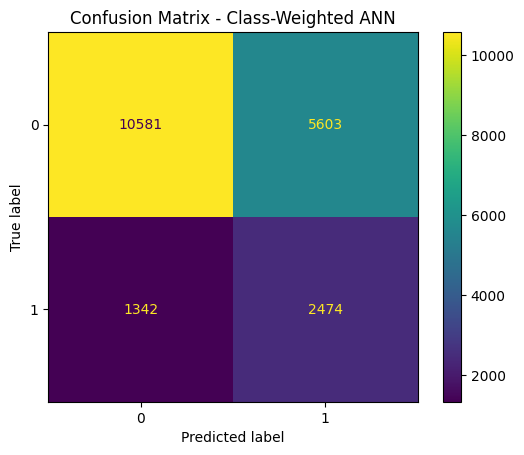

In [41]:
# Optional: confusion matrix for the selected final model
# Change final_model_name and final_model_predictions after reviewing the comparison table.

final_model_name = 'Class-Weighted ANN'
final_model_predictions = y_pred_weighted_ann
final_model_y_true = y_test

cm = confusion_matrix(final_model_y_true, final_model_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f'Confusion Matrix - {final_model_name}')
plt.show()


## 7. Model-Based Loan Readiness Scoring

To connect the final model to the business proposal, the selected **Class-Weighted ANN** is translated into a **model-based loan readiness score**.

This section does **not** create an official bank credit score.  
Instead, it converts the model's predicted default probability into:
- a **0–100 readiness score**
- a **300–850 style risk score**
- **risk bands**
- a **pre-screening recommendation**
- simple **rule-based risk flags** and **readiness advice**

This makes the final output easier to explain in a business setting and moves the notebook beyond pure classification toward a practical **pre-screening and borrower-review tool**.


In [42]:
# Build a model-based loan readiness scoring table from the selected final model

score_df = test_scoring_base.copy().reset_index(drop=True)

# Add actual outcome and model probability from the final ANN
score_df['actual_target'] = y_test.astype(int)
score_df['default_probability'] = y_prob_weighted_ann

# 0-100 readiness score (higher = safer / more ready)
score_df['readiness_score_100'] = ((1 - score_df['default_probability']) * 100).round(1)

# 300-850 style score for presentation purposes
score_df['risk_score_300_850'] = (
    300 + (1 - score_df['default_probability']) * 550
).round().astype(int)

# Risk bands based on predicted default probability
score_df['risk_band'] = pd.cut(
    score_df['default_probability'],
    bins=[-0.001, 0.20, 0.40, 0.60, 1.0],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
)

def screening_rule(prob):
    if prob < 0.20:
        return 'Pass Initial Screening'
    elif prob < 0.40:
        return 'Review Recommended'
    elif prob < 0.60:
        return 'Manual Review / High Risk'
    else:
        return 'Very High Risk / Decline Candidate'

score_df['screening_decision'] = score_df['default_probability'].apply(screening_rule)

print('Scoring table shape:', score_df.shape)


Scoring table shape: (20000, 30)


In [43]:
# Helper function for safe column access
def get_val(row, col_name):
    return row[col_name] if col_name in row.index else np.nan

# Rule-based red flags for business interpretation
def generate_risk_flags(row):
    flags = []

    dti = get_val(row, 'dti')
    loan_amnt = get_val(row, 'loan_amnt')
    annual_inc = get_val(row, 'annual_inc')
    int_rate = get_val(row, 'int_rate')
    fico_low = get_val(row, 'fico_range_low')
    fico_high = get_val(row, 'fico_range_high')
    delinq_2yrs = get_val(row, 'delinq_2yrs')
    inq_last_6mths = get_val(row, 'inq_last_6mths')
    bankruptcies = get_val(row, 'pub_rec_bankruptcies')

    if pd.notna(fico_low) and pd.notna(fico_high):
        avg_fico = (fico_low + fico_high) / 2
    elif pd.notna(fico_low):
        avg_fico = fico_low
    elif pd.notna(fico_high):
        avg_fico = fico_high
    else:
        avg_fico = np.nan

    if pd.notna(dti) and dti > 20:
        flags.append('High debt-to-income ratio')
    if pd.notna(loan_amnt) and loan_amnt > 20000:
        flags.append('Large requested loan amount')
    if pd.notna(annual_inc) and annual_inc < 50000:
        flags.append('Lower income level')
    if pd.notna(int_rate) and int_rate > 15:
        flags.append('High interest rate')
    if pd.notna(avg_fico) and avg_fico < 680:
        flags.append('Lower FICO range')
    if pd.notna(delinq_2yrs) and delinq_2yrs >= 1:
        flags.append('Recent delinquency history')
    if pd.notna(inq_last_6mths) and inq_last_6mths >= 3:
        flags.append('Many recent credit inquiries')
    if pd.notna(bankruptcies) and bankruptcies >= 1:
        flags.append('Bankruptcy history')

    if len(flags) == 0:
        return 'No major red flags from selected business rules'
    return '; '.join(flags)

# Rule-based readiness advice
def generate_readiness_advice(row):
    advice = []

    dti = get_val(row, 'dti')
    loan_amnt = get_val(row, 'loan_amnt')
    annual_inc = get_val(row, 'annual_inc')
    fico_low = get_val(row, 'fico_range_low')
    fico_high = get_val(row, 'fico_range_high')
    inq_last_6mths = get_val(row, 'inq_last_6mths')

    if pd.notna(fico_low) and pd.notna(fico_high):
        avg_fico = (fico_low + fico_high) / 2
    elif pd.notna(fico_low):
        avg_fico = fico_low
    elif pd.notna(fico_high):
        avg_fico = fico_high
    else:
        avg_fico = np.nan

    if pd.notna(dti) and dti > 20:
        advice.append('Reduce debt-to-income ratio before applying')
    if pd.notna(loan_amnt) and loan_amnt > 20000:
        advice.append('Consider requesting a smaller loan amount')
    if pd.notna(annual_inc) and annual_inc < 50000:
        advice.append('Improve income strength or provide stronger income documentation')
    if pd.notna(avg_fico) and avg_fico < 680:
        advice.append('Improve credit profile before applying')
    if pd.notna(inq_last_6mths) and inq_last_6mths >= 3:
        advice.append('Avoid too many new credit inquiries in a short period')

    if len(advice) == 0:
        return 'Application appears relatively ready based on selected business rules'
    return '; '.join(advice)

score_df['risk_flags'] = score_df.apply(generate_risk_flags, axis=1)
score_df['readiness_advice'] = score_df.apply(generate_readiness_advice, axis=1)

preview_cols = [
    'loan_amnt', 'annual_inc', 'dti', 'int_rate',
    'fico_range_low', 'fico_range_high',
    'default_probability', 'readiness_score_100', 'risk_score_300_850',
    'risk_band', 'screening_decision', 'risk_flags', 'readiness_advice',
    'actual_target'
]
preview_cols = [col for col in preview_cols if col in score_df.columns]

display(score_df[preview_cols].head(10))


,loan_amnt,annual_inc,dti,int_rate,fico_range_low,fico_range_high,default_probability,readiness_score_100,risk_score_300_850,risk_band,screening_decision,risk_flags,readiness_advice,actual_target
0,16800,54000.0,19.450001,0.1367,675,679,0.641537,35.799999,497,Very High Risk,Very High Risk / Decline Candidate,Lower FICO range,Improve credit profile before applying,0
1,17500,69750.0,1.720000,0.1205,690,694,0.484582,51.500000,583,High Risk,Manual Review / High Risk,No major red flags from selected business rules,Application appears relatively ready based on ...,0
2,14375,80000.0,37.320000,0.1989,695,699,0.638592,36.099998,499,Very High Risk,Very High Risk / Decline Candidate,High debt-to-income ratio,Reduce debt-to-income ratio before applying,0
3,9300,110000.0,35.869999,0.1894,715,719,0.543078,45.700001,551,High Risk,Manual Review / High Risk,High debt-to-income ratio,Reduce debt-to-income ratio before applying,0
4,20000,105000.0,2.460000,0.1261,735,739,0.576064,42.400002,533,High Risk,Manual Review / High Risk,No major red flags from selected business rules,Application appears relatively ready based on ...,0
5,8400,30000.0,17.799999,0.1199,690,694,0.401814,59.799999,629,High Risk,Manual Review / High Risk,Lower income level,Improve income strength or provide stronger in...,0
6,5500,35000.0,6.300000,0.1399,665,669,0.482764,51.700001,584,High Risk,Manual Review / High Risk,Lower income level; Lower FICO range,Improve income strength or provide stronger in...,0
7,18000,92000.0,28.889999,0.1367,675,679,0.657101,34.299999,489,Very High Risk,Very High Risk / Decline Candidate,High debt-to-income ratio; Lower FICO range,Reduce debt-to-income ratio before applying; I...,1
8,19000,65000.0,25.780001,0.0668,755,759,0.280985,71.900002,695,Moderate Risk,Review Recommended,High debt-to-income ratio,Reduce debt-to-income ratio before applying,0
9,14100,48000.0,16.629999,0.1919,690,694,0.693657,30.600000,468,Very High Risk,Very High Risk / Decline Candidate,Lower income level,Improve income strength or provide stronger in...,0


In [44]:
# Summary table by risk band

risk_summary = score_df.groupby('risk_band').agg(
    cases=('risk_band', 'count'),
    avg_default_probability=('default_probability', 'mean'),
    avg_readiness_score_100=('readiness_score_100', 'mean'),
    avg_risk_score_300_850=('risk_score_300_850', 'mean')
).round(3)

display(risk_summary)


/tmp/ipykernel_4099/666017971.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = score_df.groupby('risk_band').agg(


,cases,avg_default_probability,avg_readiness_score_100,avg_risk_score_300_850
risk_band,,,,
Low Risk,1745,0.153,84.709999,765.914
Moderate Risk,5840,0.314,68.617996,677.391
High Risk,8722,0.500,50.018002,575.100
Very High Risk,3693,0.678,32.167999,476.925


In [45]:
# Optional export files for report, PPT, or submission appendix

score_df.to_csv('loan_readiness_scoring_results.csv', index=False)
all_results_df.to_csv('model_comparison_results.csv', index=False)

print('Saved: loan_readiness_scoring_results.csv')
print('Saved: model_comparison_results.csv')


Saved: loan_readiness_scoring_results.csv
Saved: model_comparison_results.csv


## 8. Discussion, Assumptions, Limitations, and Improvement

### Assumptions
- The historical LendingClub loan data is assumed to be accurate enough for supervised learning.
- The relationship between borrower features and default risk is assumed to remain reasonably stable over time.
- The sampled dataset is assumed to be large enough to represent the broader lending pattern in the cleaned file.

### Limitations
- The ANN is still a relatively **black-box** model compared with simpler methods such as Logistic Regression.
- The model is trained on historical platform data, so performance may weaken if economic conditions or borrower behavior change.
- This project uses structured borrower and loan variables only. It does not include macroeconomic indicators or external credit bureau data.
- The score generated in Section 7 is a **model-based pre-screening score**, not an official lending score and not a final underwriting decision.

### Bias and Ethical Risk
- Historical lending data may contain bias related to income, geography, or prior approval patterns.
- A model trained on historical outcomes can reproduce those patterns if not reviewed carefully.
- Because of this risk, the model should support human decision-making rather than replace it.

### Potential Improvements
- Tune ANN architecture further through systematic hyperparameter search.
- Test additional threshold values and class-weight settings.
- Add explainability tools such as SHAP for stronger case-level interpretation.
- Compare results with additional tabular models if allowed by the course scope.
- Add time-based validation to test whether the model generalizes across different economic periods.

### Final Business Interpretation
The rerun results support the proposal in two ways:
1. the notebook predicts default probability with an ANN-based model
2. it translates that probability into a **loan readiness / pre-screening score**

The scoring summary also shows a meaningful separation across risk bands. In the current run, the **Low Risk** group contains **1,745** cases with an average default probability of **0.153** and an average readiness score of **84.710**, while the **Very High Risk** group contains **3,693** cases with an average default probability of **0.678** and an average readiness score of **32.168**. This indicates that the score is not just a cosmetic transformation: it creates a usable ordering of borrowers for screening support and review prioritization.

Overall, the notebook now functions as more than a classification exercise. It provides a business-facing output that can support screening, prioritization, and borrower review while still keeping the final decision under human control.
